# Final Report: Near-Earth Object Similarity and Hazard Assessment

This notebook consolidates the final project analysis into one report by combining:

- **Q1:** Similarity-based asteroid grouping (unsupervised clustering)
- **Q2:** Hazard factor exploration (distance, size, speed, and energy proxy)

All analyses use the shared SQLite loader path for a consistent and reproducible data pipeline.

In [20]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

from data_loader import load_neows_data

pd.set_option("display.max_columns",None)
pd.set_option("display.width",200)
pd.set_option("display.max_colwidth",100)
pd.set_option("display.expand_frame_repr",False)
pd.set_option("display.float_format","{:,.6f}".format)

sns.set_style("whitegrid")

## 1) Data Loading and Baseline Validation

In [21]:
df_all,df_clean,df_daily=load_neows_data()

print("Shapes")
print("- df_all:",df_all.shape)
print("- df_clean:",df_clean.shape)
print("- df_daily:",df_daily.shape)

required_cols=[
    "id","neo_reference_id","name","nasa_jpl_url",
    "absolute_magnitude_h","estimated_diameter_min_km","estimated_diameter_max_km",
    "is_potentially_hazardous_asteroid","close_approach_date","close_approach_date_full",
    "relative_velocity_kph","miss_distance_km","orbiting_body","is_sentry_object","ingested_at"
]
missing=[c for c in required_cols if c not in df_clean.columns]
if missing:
    raise ValueError(f"Missing required columns in df_clean: {missing}")

print("\nCleaned preview:")
display(df_clean.head(10))

print("\nDaily summary preview:")
display(df_daily.head(10))

Shapes
- df_all: (60, 15)
- df_clean: (60, 15)
- df_daily: (7, 7)

Cleaned preview:


,id,neo_reference_id,name,nasa_jpl_url,absolute_magnitude_h,estimated_diameter_min_km,estimated_diameter_max_km,is_potentially_hazardous_asteroid,close_approach_date,close_approach_date_full,relative_velocity_kph,miss_distance_km,orbiting_body,is_sentry_object,ingested_at
0,43,54347996,(2023 DZ2),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=54347996,24.280000,0.037030,0.082802,0,2026-04-04,2026-04-04 02:04:00,"26,061.586230","1,012,421.611768",Earth,0,2026-04-04 22:29:29
1,51,54607052,(2026 FF7),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=54607052,27.472000,0.008514,0.019039,0,2026-04-04,2026-04-04 19:50:00,"47,046.660716","1,771,462.818570",Earth,0,2026-04-04 22:29:29
2,31,54489663,(2024 TB7),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=54489663,29.230000,0.003789,0.008473,0,2026-04-07,2026-04-07 14:21:00,"27,085.378477","1,863,693.645372",Earth,0,2026-04-04 22:29:29
3,20,54136202,(2021 GN6),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=54136202,26.960000,0.010778,0.024101,0,2026-04-06,2026-04-06 08:49:00,"25,375.561708","2,218,033.778217",Earth,0,2026-04-04 22:29:29
4,45,54606897,(2026 FG5),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=54606897,25.037000,0.026131,0.058431,0,2026-04-04,2026-04-04 03:27:00,"89,661.031738","3,296,996.238325",Earth,0,2026-04-04 22:29:29
5,4,54269399,(2022 GE2),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=54269399,26.930000,0.010928,0.024437,0,2026-04-10,2026-04-10 02:12:00,"32,979.981442","4,612,750.390073",Earth,0,2026-04-04 22:29:29
6,48,54606916,(2026 FB6),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=54606916,27.818000,0.007260,0.016235,0,2026-04-04,2026-04-04 03:48:00,"24,645.019492","4,819,928.270799",Earth,0,2026-04-04 22:29:29
7,60,54607045,(2026 FW6),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=54607045,25.625000,0.019932,0.044570,0,2026-04-05,2026-04-05 03:06:00,"71,346.648168","5,899,224.349117",Earth,0,2026-04-04 22:29:29
8,49,54606976,(2026 FH6),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=54606976,24.961000,0.027062,0.060512,0,2026-04-04,2026-04-04 11:03:00,"29,241.060676","6,934,107.063800",Earth,0,2026-04-04 22:29:29
9,11,54607046,(2026 FX6),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=54607046,26.169000,0.015515,0.034693,0,2026-04-08,2026-04-08 20:51:00,"22,301.218235","7,994,377.060615",Earth,0,2026-04-04 22:29:29



Daily summary preview:


,close_approach_date,approach_count,avg_miss_distance_km,min_miss_distance_km,max_miss_distance_km,avg_relative_velocity_kph,hazardous_count
0,2026-04-04,19,"29,524,329.592412","1,012,421.611768","70,550,795.833330","43,590.173960",0
1,2026-04-05,9,"35,215,067.227464","5,899,224.349117","69,262,006.383494","43,170.037222",0
2,2026-04-06,9,"37,362,523.976888","2,218,033.778217","71,548,953.871626","49,204.926389",0
3,2026-04-07,6,"23,444,108.317172","1,863,693.645372","43,650,761.415411","43,769.186670",0
4,2026-04-08,6,"38,430,535.965165","7,994,377.060615","66,627,537.253915","43,205.269071",0
5,2026-04-09,6,"40,230,783.819955","21,833,872.555997","69,567,435.747059","45,294.568429",0
6,2026-04-10,5,"40,075,679.769969","4,612,750.390073","73,671,279.944145","46,606.304028",0


## 2)  Similarity Grouping with KMeans

Objective: identify similarity-based asteroid subgroups using continuous physical/approach features.

In [22]:
FEATURE_COLS=[
    "absolute_magnitude_h",
    "estimated_diameter_min_km",
    "estimated_diameter_max_km",
    "relative_velocity_kph",
    "miss_distance_km",
]

missing_features=[c for c in FEATURE_COLS if c not in df_clean.columns]
if missing_features:
    raise ValueError(f"Missing required feature columns: {missing_features}")

df_features=df_clean[FEATURE_COLS].copy().dropna().reset_index(drop=True)
print("Feature matrix shape:",df_features.shape)
display(df_features.describe().T.style.format("{:,.6f}"))

scaler=StandardScaler()
X_scaled=scaler.fit_transform(df_features)
print("Scaled matrix shape:",X_scaled.shape)

Feature matrix shape: (60, 5)


,count,mean,std,min,25%,50%,75%,max
absolute_magnitude_h,60.000000,25.773317,2.140433,19.440000,24.443500,25.765000,27.230000,30.270000
estimated_diameter_min_km,60.000000,0.031791,0.048449,0.002347,0.009519,0.018688,0.034377,0.343997
estimated_diameter_max_km,60.000000,0.071087,0.108336,0.005249,0.021286,0.041788,0.076870,0.769201
relative_velocity_kph,60.000000,"44,770.560715","24,507.272732","14,378.326912","26,829.430415","36,280.577913","61,969.512103","122,832.326871"
miss_distance_km,60.000000,"33,786,192.509310","22,666,928.601814","1,012,421.611768","14,184,185.062153","31,746,262.166302","51,911,661.053872","73,671,279.944145"


Scaled matrix shape: (60, 5)


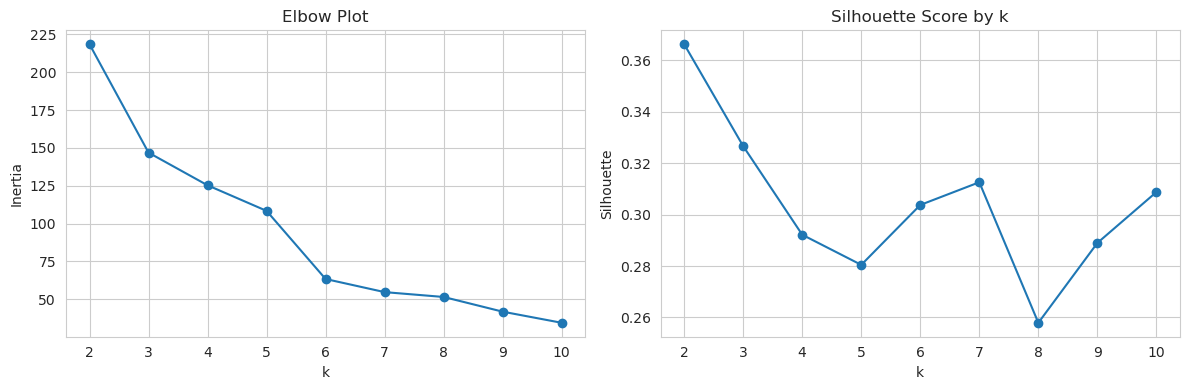

,k,inertia,silhouette
0,2,218.46,0.3662
1,3,146.84,0.3266
2,4,125.25,0.2922
3,5,108.34,0.2804
4,6,63.31,0.3037
5,7,54.65,0.3126
6,8,51.45,0.2579
7,9,41.73,0.2890
8,10,34.38,0.3088


In [23]:
# Optional Windows/MKL warning mitigation from sklearn guidance
os.environ.setdefault("OMP_NUM_THREADS","1")

k_values=list(range(2,11))
inertia_vals=[]
silhouette_vals=[]

for k in k_values:
    km=KMeans(n_clusters=k,random_state=42,n_init="auto")
    labels=km.fit_predict(X_scaled)
    inertia_vals.append(km.inertia_)
    silhouette_vals.append(silhouette_score(X_scaled,labels))

diag_df=pd.DataFrame({"k":k_values,"inertia":inertia_vals,"silhouette":silhouette_vals})

fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].plot(k_values,inertia_vals,marker="o")
ax[0].set_title("Elbow Plot")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia")

ax[1].plot(k_values,silhouette_vals,marker="o")
ax[1].set_title("Silhouette Score by k")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.show()

display(diag_df.style.format({"k":"{:d}","inertia":"{:,.2f}","silhouette":"{:.4f}"}))

In [24]:
# Selected from diagnostics used in prior q1 work
K_CHOSEN=4
kmeans=KMeans(n_clusters=K_CHOSEN,random_state=42,n_init="auto")
cluster_labels=kmeans.fit_predict(X_scaled)

df_grouped=df_clean.loc[df_features.index].copy()
df_grouped["cluster_id"]=cluster_labels

print("Cluster counts:")
display(df_grouped["cluster_id"].value_counts().sort_index().rename("count").to_frame())

profile_agg={c:["mean","median","min","max"] for c in FEATURE_COLS}
cluster_profiles=df_grouped.groupby("cluster_id").agg(profile_agg)
cluster_profiles_flat=cluster_profiles.copy()
cluster_profiles_flat.columns=[f"{a}_{b}" for a,b in cluster_profiles_flat.columns]

print("Cluster profile summary:")
display(cluster_profiles_flat.style.format("{:,.6f}"))

Cluster counts:


,count
cluster_id,
0,32
1,12
2,5
3,11


Cluster profile summary:


,absolute_magnitude_h_mean,absolute_magnitude_h_median,absolute_magnitude_h_min,absolute_magnitude_h_max,estimated_diameter_min_km_mean,estimated_diameter_min_km_median,estimated_diameter_min_km_min,estimated_diameter_min_km_max,estimated_diameter_max_km_mean,estimated_diameter_max_km_median,estimated_diameter_max_km_min,estimated_diameter_max_km_max,relative_velocity_kph_mean,relative_velocity_kph_median,relative_velocity_kph_min,relative_velocity_kph_max,miss_distance_km_mean,miss_distance_km_median,miss_distance_km_min,miss_distance_km_max
cluster_id,,,,,,,,,,,,,,,,,,,,
0,25.957406,25.825000,23.300000,29.230000,0.021800,0.018182,0.003789,0.058151,0.048746,0.040657,0.008473,0.130029,"32,262.581817","29,347.532695","14,378.326912","89,661.031738","17,978,920.074646","20,821,025.824481","1,012,421.611768","41,024,560.829383"
1,25.163333,25.425000,23.020000,27.600000,0.029954,0.021868,0.008027,0.066154,0.066979,0.048899,0.017949,0.147924,"72,588.167042","71,596.156000","31,690.143691","122,832.326871","60,649,843.330495","67,173,874.120518","37,984,978.154599","73,671,279.944145"
2,21.570400,21.840000,19.440000,22.676000,0.150550,0.113908,0.077510,0.343997,0.336641,0.254706,0.173317,0.769201,"71,370.969576","67,585.613437","54,228.525668","96,903.898974","23,466,501.409405","15,335,437.095110","14,601,074.839485","38,044,039.573193"
3,27.813636,27.900000,25.600000,30.270000,0.008878,0.006991,0.002347,0.020163,0.019853,0.015633,0.005249,0.045086,"38,719.833853","36,336.217361","16,302.016410","65,300.015914","55,155,952.832452","55,243,837.580014","34,256,086.672233","70,550,795.833330"


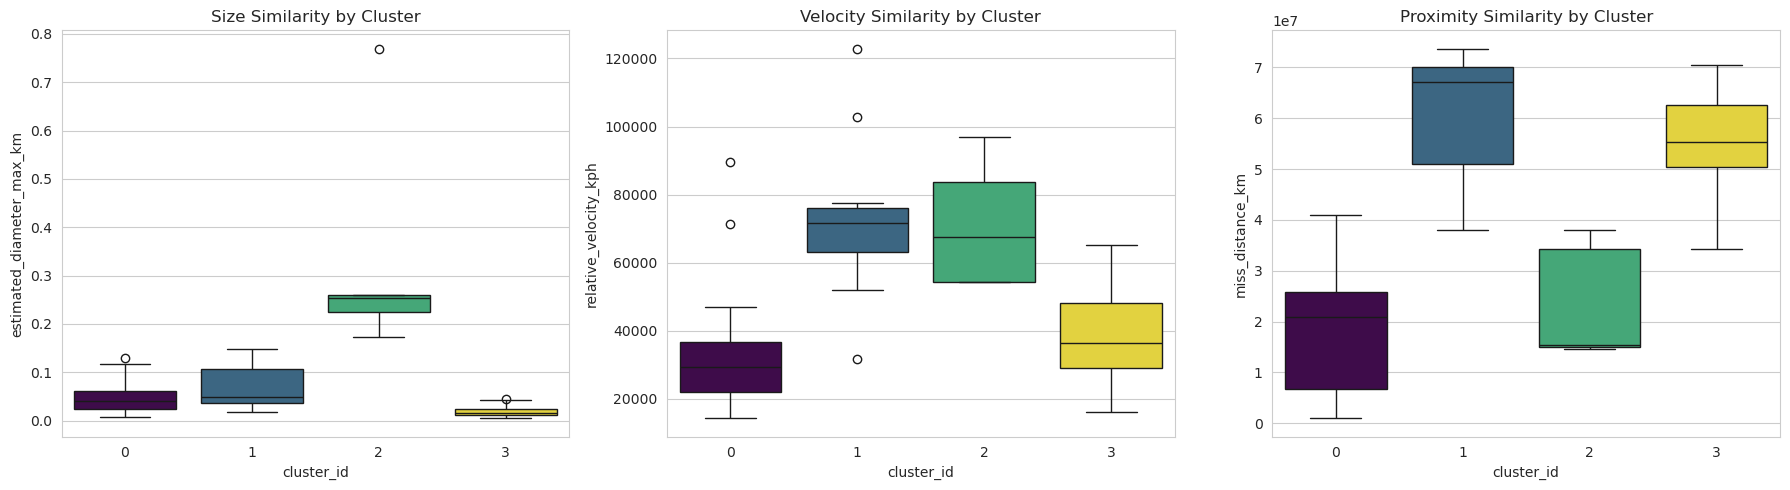

In [25]:
# Feature distributions by cluster
fig,ax=plt.subplots(1,3,figsize=(18,5))

sns.boxplot(x="cluster_id",y="estimated_diameter_max_km",hue="cluster_id",data=df_grouped,ax=ax[0],palette="viridis",legend=False)
ax[0].set_title("Size Similarity by Cluster")

sns.boxplot(x="cluster_id",y="relative_velocity_kph",hue="cluster_id",data=df_grouped,ax=ax[1],palette="viridis",legend=False)
ax[1].set_title("Velocity Similarity by Cluster")

sns.boxplot(x="cluster_id",y="miss_distance_km",hue="cluster_id",data=df_grouped,ax=ax[2],palette="viridis",legend=False)
ax[2].set_title("Proximity Similarity by Cluster")

plt.tight_layout()
plt.show()

## 3) Hazard Factors and Near-Miss Risk Context

Objective: inspect factors linked to potentially hazardous status and practical risk indicators.

In [26]:
df_hazard=df_clean.copy()

# Derived exploratory factors
ld_km=384400.0
df_hazard["miss_distance_ld"]=df_hazard["miss_distance_km"]/ld_km
df_hazard["kinetic_energy_proxy"]=(df_hazard["estimated_diameter_max_km"]**3)*(df_hazard["relative_velocity_kph"]**2)

hazard_count=int(df_hazard["is_potentially_hazardous_asteroid"].sum())
print("Number of asteroids marked as potentially hazardous:")
print(hazard_count)

near_miss_cols=[
    "id","neo_reference_id","name","nasa_jpl_url","absolute_magnitude_h",
    "estimated_diameter_min_km","estimated_diameter_max_km","is_potentially_hazardous_asteroid",
    "close_approach_date","close_approach_date_full","relative_velocity_kph","miss_distance_km",
    "orbiting_body","is_sentry_object","ingested_at","kinetic_energy_proxy","miss_distance_ld"
]

df_near=df_hazard.sort_values("miss_distance_km",ascending=True).reset_index(drop=True)

print("\nFirst 10 rows of near misses:")
display(df_near[near_miss_cols].head(10))

print("\nTop 5 Asteroids by Kinetic Energy Potential:")
display(df_hazard[["name","kinetic_energy_proxy"]].sort_values("kinetic_energy_proxy",ascending=False).head(5))

closest_ld=float(df_near.loc[0,"miss_distance_ld"])
print(f"\nThe closest asteroid missed by {closest_ld:.2f} Lunar Distances.")

Number of asteroids marked as potentially hazardous:
0

First 10 rows of near misses:


,id,neo_reference_id,name,nasa_jpl_url,absolute_magnitude_h,estimated_diameter_min_km,estimated_diameter_max_km,is_potentially_hazardous_asteroid,close_approach_date,close_approach_date_full,relative_velocity_kph,miss_distance_km,orbiting_body,is_sentry_object,ingested_at,kinetic_energy_proxy,miss_distance_ld
0,43,54347996,(2023 DZ2),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=54347996,24.280000,0.037030,0.082802,0,2026-04-04,2026-04-04 02:04:00,"26,061.586230","1,012,421.611768",Earth,0,2026-04-04 22:29:29,"385,586.328515",2.633771
1,51,54607052,(2026 FF7),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=54607052,27.472000,0.008514,0.019039,0,2026-04-04,2026-04-04 19:50:00,"47,046.660716","1,771,462.818570",Earth,0,2026-04-04 22:29:29,"15,274.870608",4.608384
2,31,54489663,(2024 TB7),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=54489663,29.230000,0.003789,0.008473,0,2026-04-07,2026-04-07 14:21:00,"27,085.378477","1,863,693.645372",Earth,0,2026-04-04 22:29:29,446.261844,4.848319
3,20,54136202,(2021 GN6),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=54136202,26.960000,0.010778,0.024101,0,2026-04-06,2026-04-06 08:49:00,"25,375.561708","2,218,033.778217",Earth,0,2026-04-04 22:29:29,"9,014.699709",5.770119
4,45,54606897,(2026 FG5),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=54606897,25.037000,0.026131,0.058431,0,2026-04-04,2026-04-04 03:27:00,"89,661.031738","3,296,996.238325",Earth,0,2026-04-04 22:29:29,"1,603,715.771814",8.576993
5,4,54269399,(2022 GE2),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=54269399,26.930000,0.010928,0.024437,0,2026-04-10,2026-04-10 02:12:00,"32,979.981442","4,612,750.390073",Earth,0,2026-04-04 22:29:29,"15,871.601440",11.999871
6,48,54606916,(2026 FB6),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=54606916,27.818000,0.007260,0.016235,0,2026-04-04,2026-04-04 03:48:00,"24,645.019492","4,819,928.270799",Earth,0,2026-04-04 22:29:29,"2,598.832388",12.538835
7,60,54607045,(2026 FW6),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=54607045,25.625000,0.019932,0.044570,0,2026-04-05,2026-04-05 03:06:00,"71,346.648168","5,899,224.349117",Earth,0,2026-04-04 22:29:29,"450,678.755499",15.346577
8,49,54606976,(2026 FH6),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=54606976,24.961000,0.027062,0.060512,0,2026-04-04,2026-04-04 11:03:00,"29,241.060676","6,934,107.063800",Earth,0,2026-04-04 22:29:29,"189,455.047057",18.038780
9,11,54607046,(2026 FX6),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=54607046,26.169000,0.015515,0.034693,0,2026-04-08,2026-04-08 20:51:00,"22,301.218235","7,994,377.060615",Earth,0,2026-04-04 22:29:29,"20,767.160071",20.797027



Top 5 Asteroids by Kinetic Energy Potential:


,name,kinetic_energy_proxy
17,(2018 PG21),"1,345,542,760.752697"
36,(2020 HK7),"155,168,098.955990"
16,(2026 FL5),"80,283,381.303732"
33,(2020 HD5),"52,068,555.641016"
35,(2022 GR2),"24,140,446.282739"



The closest asteroid missed by 2.63 Lunar Distances.


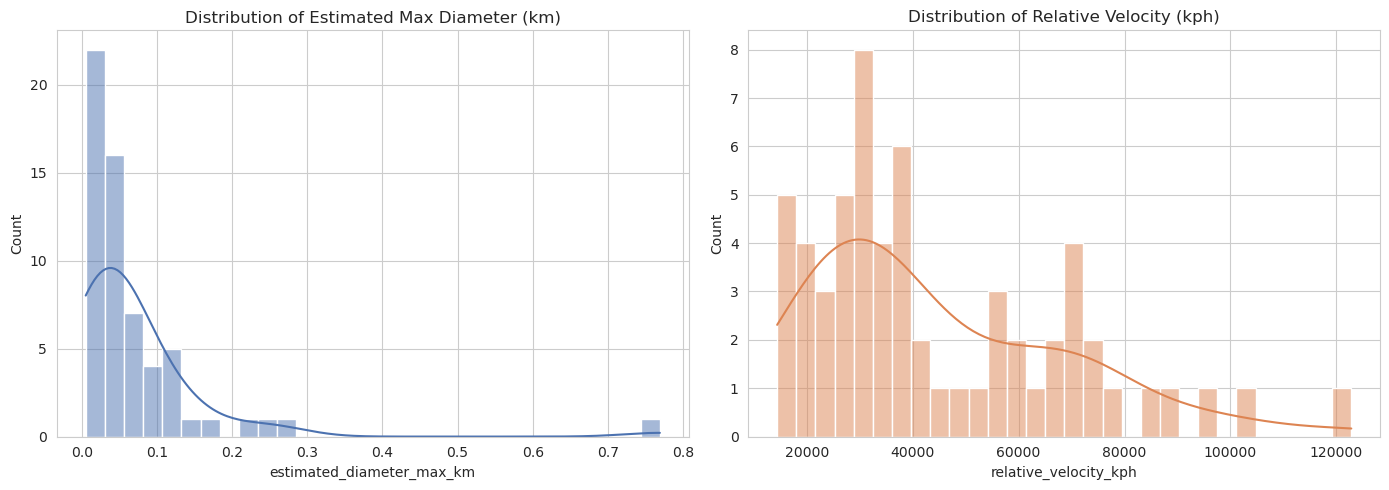

In [27]:
fig,ax=plt.subplots(1,2,figsize=(14,5))

sns.histplot(df_hazard["estimated_diameter_max_km"],bins=30,kde=True,ax=ax[0],color="#4c72b0")
ax[0].set_title("Distribution of Estimated Max Diameter (km)")
ax[0].set_xlabel("estimated_diameter_max_km")

sns.histplot(df_hazard["relative_velocity_kph"],bins=30,kde=True,ax=ax[1],color="#dd8452")
ax[1].set_title("Distribution of Relative Velocity (kph)")
ax[1].set_xlabel("relative_velocity_kph")

plt.tight_layout()
plt.show()

### 4 Similarity Structure
The clustering confirms that the NEO sample is **not homogeneous**. It separates into interpretable groups defined by combinations of:
- physical scale (`estimated_diameter_*`, `absolute_magnitude_h`),
- motion (`relative_velocity_kph`), and
- approach geometry (`miss_distance_km`).

## 5) Cluster Types

Based on profile summaries and visual distributions:

- **Cluster 0 — Standard Population**
  - moderate size, moderate speed, moderate approach distance.

- **Cluster 1 — High-Velocity Travelers**
  - elevated relative velocity compared with sample center.

- **Cluster 2 — Small/Closer-Range Group**
  - generally smaller diameters and tighter distance envelope in this dataset.

- **Cluster 3 — Large Giants**
  - lower absolute magnitude (brighter/larger), largest diameter ranges.

In [28]:
out_dir=Path.cwd()/"outputs"
out_dir.mkdir(parents=True,exist_ok=True)

clustered_path=out_dir/"clustered_asteroids.csv"
profiles_path=out_dir/"cluster_profiles.csv"
diag_path=out_dir/"cluster_k_diagnostics.csv"
hazard_path=out_dir/"hazard_factor_table.csv"
near_miss_path=out_dir/"near_miss_top10.csv"

df_grouped.to_csv(clustered_path,index=False,float_format="%.6f")
cluster_profiles_flat.to_csv(profiles_path,float_format="%.6f")
diag_df.to_csv(diag_path,index=False,float_format="%.6f")
df_hazard.to_csv(hazard_path,index=False,float_format="%.6f")
df_near[near_miss_cols].head(10).to_csv(near_miss_path,index=False,float_format="%.6f")

print(f"Saved: {clustered_path}")
print(f"Saved: {profiles_path}")
print(f"Saved: {diag_path}")
print(f"Saved: {hazard_path}")
print(f"Saved: {near_miss_path}")

Saved: /home/pa11ie/Projects/COSC301/301-space-traffic-control/python/outputs/clustered_asteroids.csv
Saved: /home/pa11ie/Projects/COSC301/301-space-traffic-control/python/outputs/cluster_profiles.csv
Saved: /home/pa11ie/Projects/COSC301/301-space-traffic-control/python/outputs/cluster_k_diagnostics.csv
Saved: /home/pa11ie/Projects/COSC301/301-space-traffic-control/python/outputs/hazard_factor_table.csv
Saved: /home/pa11ie/Projects/COSC301/301-space-traffic-control/python/outputs/near_miss_top10.csv
